# Introducción teórica

Un **conversor analógico-digital (ADC)** permite transformar una señal analógica en una representación digital. Este proceso involucra principalmente dos etapas: el **muestreo**, que discretiza la señal en el tiempo (eje x), y la **cuantización**, que discretiza su amplitud (eje y).

## Muestreo

El muestreo consiste en obtener valores de la señal analógica a intervalos regulares. La frecuencia con la que se toman estas muestras se denomina **frecuencia de muestreo** \(f_s\).

Según el **teorema de Nyquist-Shannon**, para evitar el aliasing y poder reconstruir correctamente una señal limitada en banda, debe cumplirse:

$$
f_s \geq 2f_{\max}
$$

## Cuantización

La cuantización se basa en aproximar cada muestra de la señal a uno de los niveles de amplitud disponibles en el ADC. Para un conversor de (B) bits, existen:

$$
2^B
$$

niveles de cuantización.

Si el rango de entrada del ADC es V_F, el paso de cuantización q se obtiene mediante:

$$
q = \frac{2V_F}{2^B}
$$

## Ruido de entrada

Además del proceso de cuantización, la señal que ingresa al ADC puede estar contaminada por ruido.

La señal original se representa como \(s[n]\), mientras que \(n[n]\) representa el ruido. Entonces, la señal con ruido que ingresa al ADC, antes de ser cuantizada, es:

$$
s_R[n] = s[n] + n[n]
$$

Posteriormente, esta señal es cuantizada, obteniéndose:

$$
s_q[n] = Q\{s_R[n]\}
$$

donde \(Q\{\}\) representa la operación de cuantización.

## Error de cuantización

El proceso de cuantización introduce una diferencia entre la señal ruidosa antes de cuantizar y la señal obtenida después de la cuantización. Esta diferencia se denomina **error de cuantización** y se define como:

$$
n_q[n] = s_q[n] - s_R[n]
$$

donde \(n_q[n]\) es el error de cuantización, \(s_q[n]\) es la señal cuantizada y \(s_R[n]\) es la señal ruidosa antes de la cuantización.

Bajo el modelo ideal de cuantización, este error puede aproximarse mediante una distribución uniforme en el intervalo:

$$
-\frac{q}{2} \leq n_q[n] < \frac{q}{2}
$$

Por lo tanto, la potencia media del ruido de cuantización es:

$$
P_q = \frac{q^2}{12}
$$

## Potencia del ruido de entrada

La potencia del ruido agregado a la señal se establece de forma proporcional al ruido de cuantización:

$$
P_n = k_n P_q
$$


donde kn es un factor de escala que determina cuánto ruido agregado tenés respecto del ruido de cuantización.

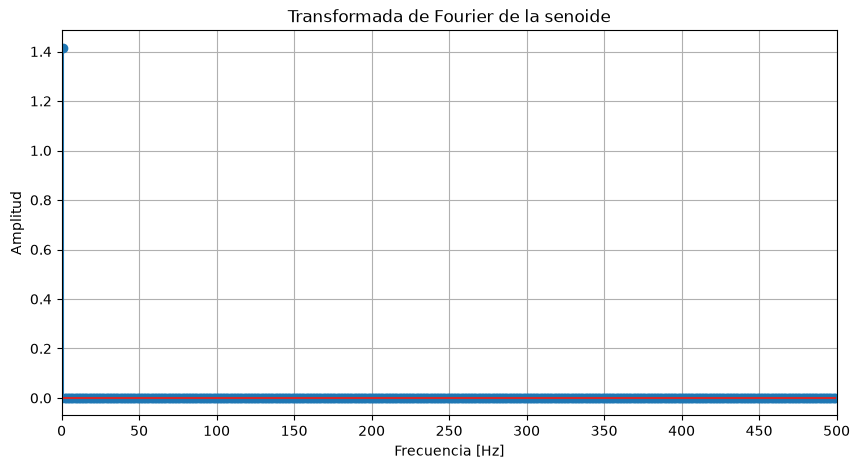

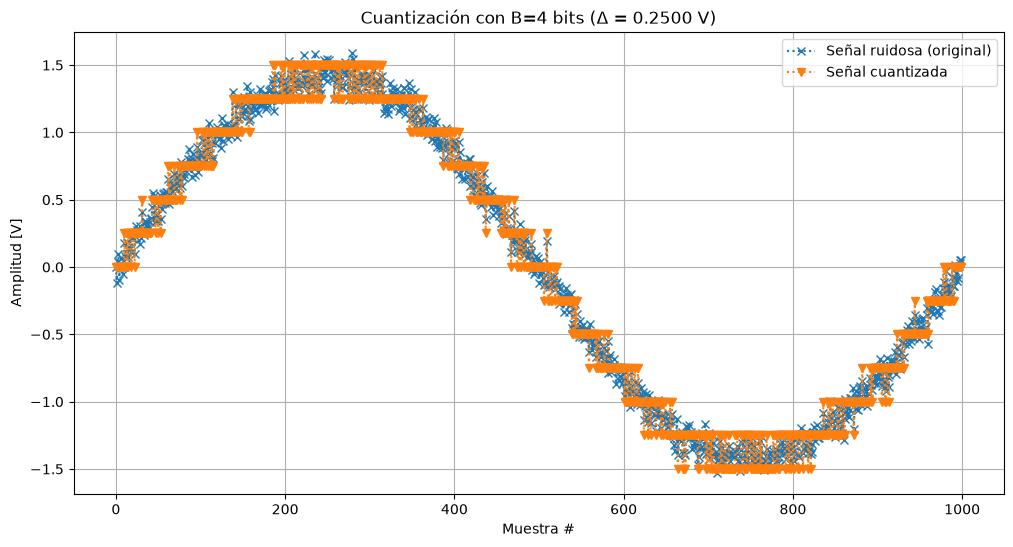

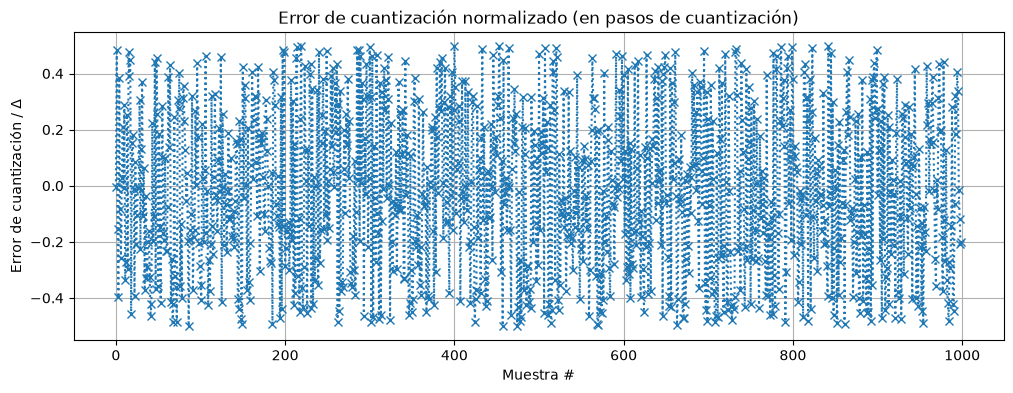

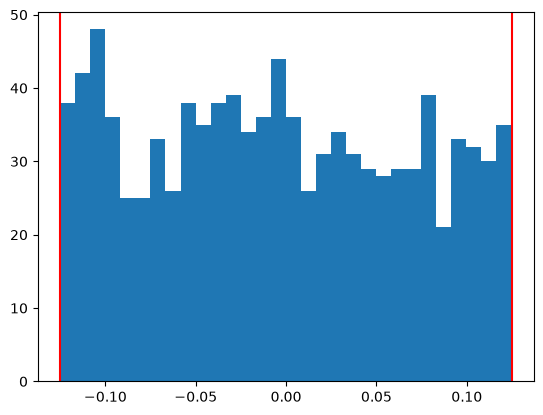

In [2]:
# -*- coding: utf-8 -*-
# -------------------------------------------------------------------
# IMPORTACION DE MODULOS
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest

# -------------------------------------------------------------------
# DEFINICION DE CONSTANTES
fs = 1000      # Frecuencia de muestreo (Hz)
N = 1000       # Cantidad de muestras
vmax = np.sqrt(2)   # Amplitud máxima de la senoide
dc = 0         # Offset (componente continua)
ff = 1         # Frecuencia de la senoide (Hz)
ph = 0         # Fase inicial (rad)

Psen = 1       # Potencia media de la senoide (Watt)
ur = 0         # Media del ruido

#%% Ruido analogico

B = 4 #Bits

Vfs = 2     #Vfulls

qq = 2 * Vfs / (2 ** B) #Paso de cuantizacion


Pq = qq**2 / 12 #Potencia del ruido de cuantizacion 

kn = 1     #Factor de escala 

Pn = kn * Pq  # ruido analogico

SNR = 10 * np.log10(Psen / Pn)

#%%
# FUNCIONES

def gen_sin(vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs):
    """
    Genera una señal senoidal.
    Retorna: vector de tiempos tt y la señal xx.
    """
    tt = np.arange(0, stop=nn/fs, step=1/fs)
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx

def gen_noise(Pn=Pn, ur=ur, nn=N):
    
    desv_est_r = np.sqrt(Pn)
    
    ruido = np.random.normal(ur, desv_est_r, nn)
    
    return ruido

# -------------------------------------------------------------------
#%% main

# 1. Generar la senoide
tt, xx = gen_sin(vmax, dc, ff, ph, N, fs) # xx es mi s

# 2. Generar el ruido
ruido = gen_noise() # ruido es mi n

# 3. Señal ruidosa (senoide + ruido) - USAMOS EL NOMBRE QUE USA EL PROFESOR
noisy_xx = xx + ruido # es mi sR[n]

# 4. Vector de frecuencias
frec = np.arange(0, N//2) * fs / N

# 5. FFT de la senoide pura
X_fft = np.fft.fft(xx)

# 6. Módulo de la FFT
modulo = np.abs(X_fft[:N//2]) / N
modulo[1:] = 2 * modulo[1:]

# 7. Gráfico de la transformada
plt.figure(figsize=(10, 5))

plt.stem(frec, modulo)

plt.xlim(0, fs/2)       # 0 a 500 Hz
plt.xticks(np.arange(0, 501, 50))

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud")
plt.title("Transformada de Fourier de la senoide")
plt.grid(True)

plt.show()
# ===================================================================


#%% 

# Señal cuantizada 
xx_q = np.round( noisy_xx / qq) * qq   # Es mi sq[n] senal cuantizada

#%% Error de cuantización

nq = xx_q - noisy_xx

# Graficar señal ruidosa y señal cuantizada
plt.figure(figsize=(12, 6))
plt.plot( noisy_xx , ':x', label='Señal ruidosa (original)')
plt.plot(xx_q, ':v', label='Señal cuantizada')
plt.xlabel("Muestra #")
plt.ylabel("Amplitud [V]")
plt.title(f"Cuantización con B={B} bits (Δ = {qq:.4f} V)")
plt.legend()
plt.grid(True)

# Graficar el error de cuantización normalizado
plt.figure(figsize=(12, 4))
plt.plot(nq / qq, ':x')
plt.xlabel("Muestra #")
plt.ylabel("Error de cuantización / Δ")
plt.title("Error de cuantización normalizado (en pasos de cuantización)")
plt.grid(True)

plt.show()

plt.hist(nq, bins=30)
plt.axvline(x=-qq/2, color='r')
plt.axvline(x=qq/2, color='r')
plt.show()



 # Bits = 4 kn = 1/10

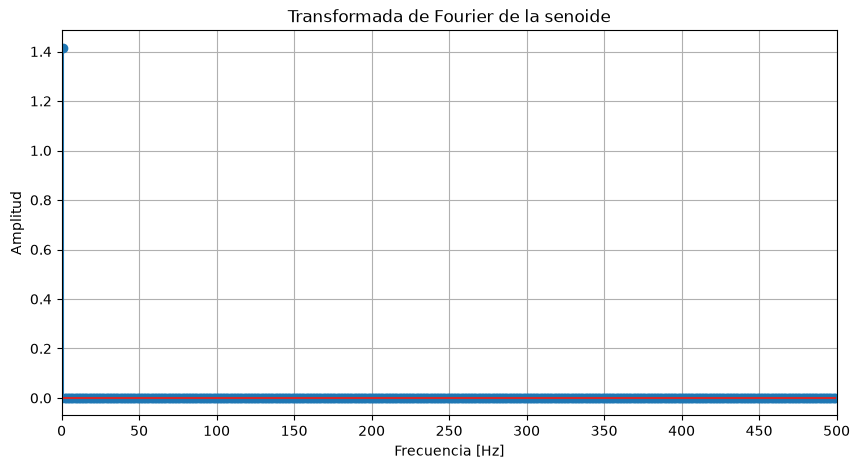

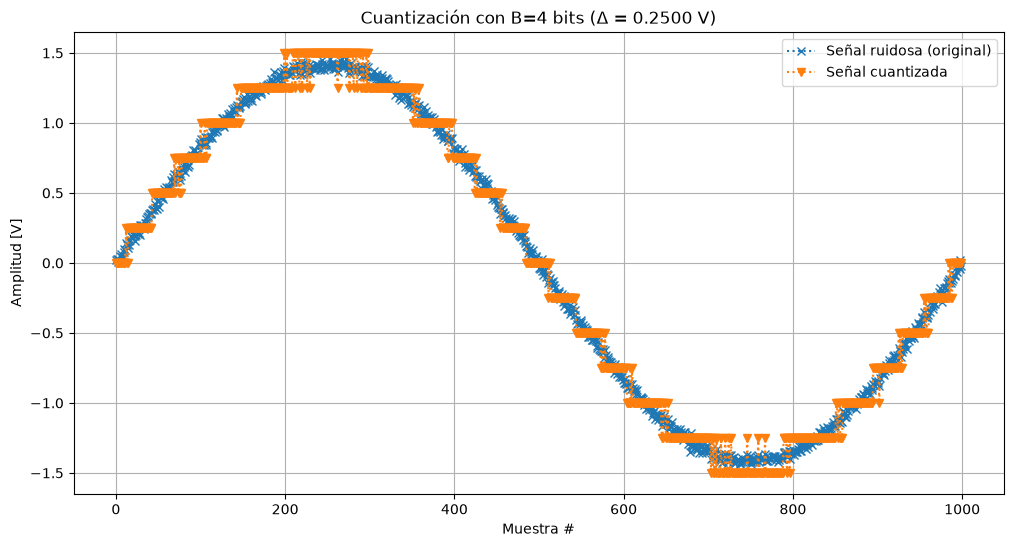

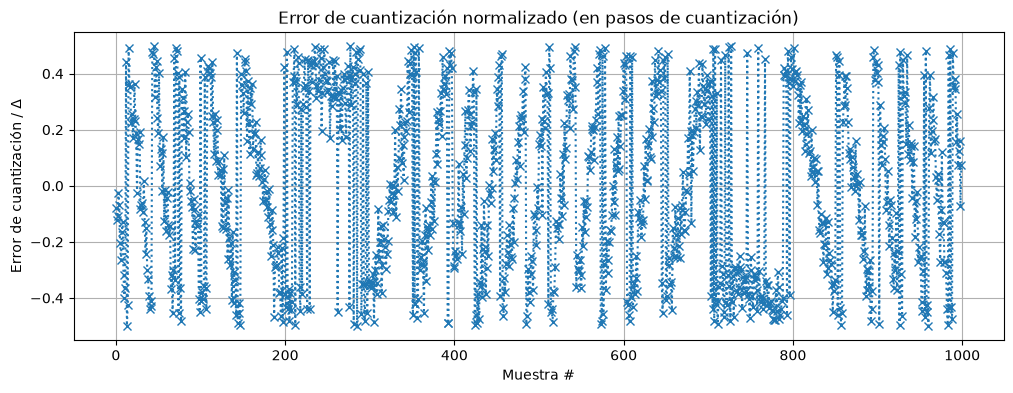

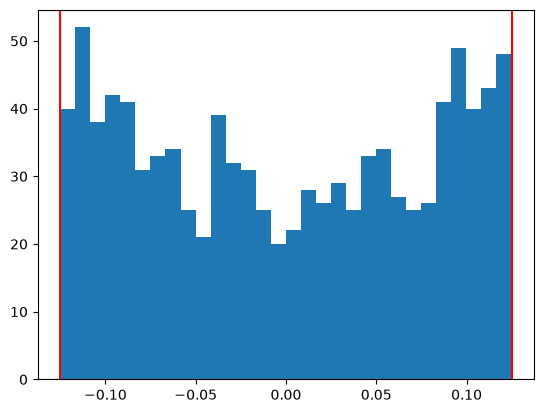

In [3]:
# -*- coding: utf-8 -*-
# -------------------------------------------------------------------
# IMPORTACION DE MODULOS
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest

# -------------------------------------------------------------------
# DEFINICION DE CONSTANTES
fs = 1000      # Frecuencia de muestreo (Hz)
N = 1000       # Cantidad de muestras
vmax = np.sqrt(2)   # Amplitud máxima de la senoide
dc = 0         # Offset (componente continua)
ff = 1         # Frecuencia de la senoide (Hz)
ph = 0         # Fase inicial (rad)

Psen = 1       # Potencia media de la senoide (Watt)
ur = 0         # Media del ruido

#%% Ruido analogico

B = 4 #Bits

Vfs = 2     #Vfulls

qq = 2 * Vfs / (2 ** B) #Paso de cuantizacion


Pq = qq**2 / 12 #Potencia del ruido de cuantizacion 

kn = 1/10     #Factor de escala 

Pn = kn * Pq  # ruido analogico

SNR = 10 * np.log10(Psen / Pn)

#%%
# FUNCIONES

def gen_sin(vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs):
    """
    Genera una señal senoidal.
    Retorna: vector de tiempos tt y la señal xx.
    """
    tt = np.arange(0, stop=nn/fs, step=1/fs)
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx

def gen_noise(Pn=Pn, ur=ur, nn=N):
    
    desv_est_r = np.sqrt(Pn)
    
    ruido = np.random.normal(ur, desv_est_r, nn)
    
    return ruido

# -------------------------------------------------------------------
#%% main

# 1. Generar la senoide
tt, xx = gen_sin(vmax, dc, ff, ph, N, fs) # xx es mi s

# 2. Generar el ruido
ruido = gen_noise() # ruido es mi n

# 3. Señal ruidosa (senoide + ruido) - USAMOS EL NOMBRE QUE USA EL PROFESOR
noisy_xx = xx + ruido # es mi sR[n]

# 4. Vector de frecuencias
frec = np.arange(0, N//2) * fs / N

# 5. FFT de la senoide pura
X_fft = np.fft.fft(xx)

# 6. Módulo de la FFT
modulo = np.abs(X_fft[:N//2]) / N
modulo[1:] = 2 * modulo[1:]

# 7. Gráfico de la transformada
plt.figure(figsize=(10, 5))

plt.stem(frec, modulo)

plt.xlim(0, fs/2)       # 0 a 500 Hz
plt.xticks(np.arange(0, 501, 50))

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud")
plt.title("Transformada de Fourier de la senoide")
plt.grid(True)

plt.show()
# ===================================================================


#%% 

# Señal cuantizada 
xx_q = np.round( noisy_xx / qq) * qq   # Es mi sq[n] senal cuantizada

#%% Error de cuantización

nq = xx_q - noisy_xx

# Graficar señal ruidosa y señal cuantizada
plt.figure(figsize=(12, 6))
plt.plot( noisy_xx , ':x', label='Señal ruidosa (original)')
plt.plot(xx_q, ':v', label='Señal cuantizada')
plt.xlabel("Muestra #")
plt.ylabel("Amplitud [V]")
plt.title(f"Cuantización con B={B} bits (Δ = {qq:.4f} V)")
plt.legend()
plt.grid(True)

# Graficar el error de cuantización normalizado
plt.figure(figsize=(12, 4))
plt.plot(nq / qq, ':x')
plt.xlabel("Muestra #")
plt.ylabel("Error de cuantización / Δ")
plt.title("Error de cuantización normalizado (en pasos de cuantización)")
plt.grid(True)

plt.show()

plt.hist(nq, bins=30)
plt.axvline(x=-qq/2, color='r')
plt.axvline(x=qq/2, color='r')
plt.show()

  # Bits = 8 Kn = 1/10

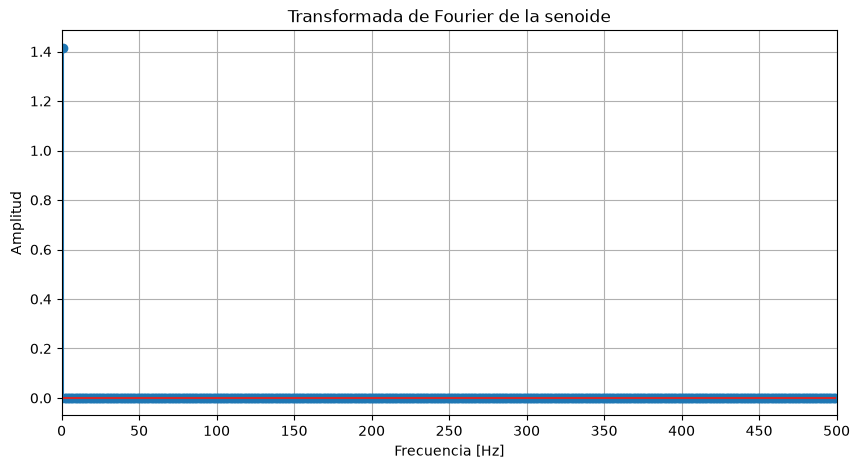

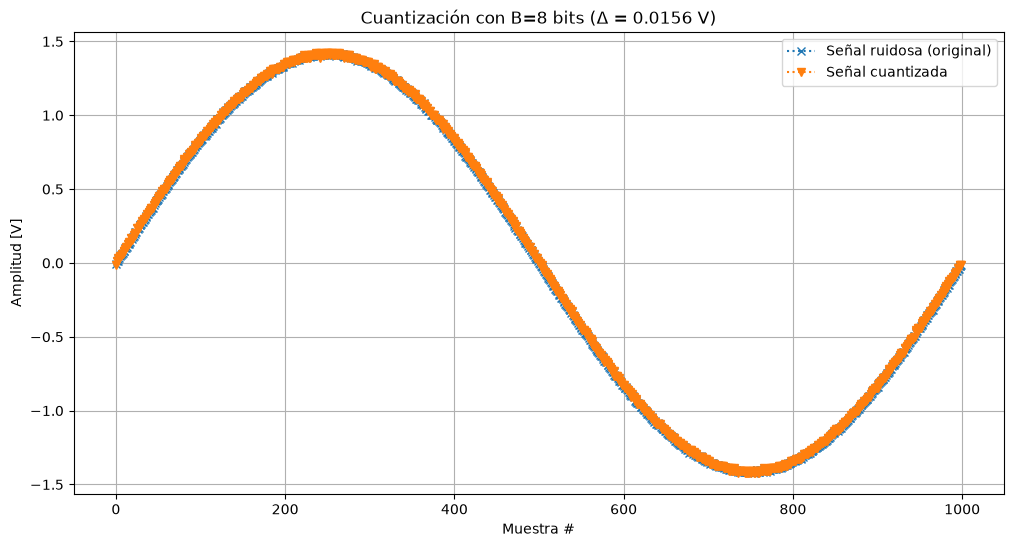

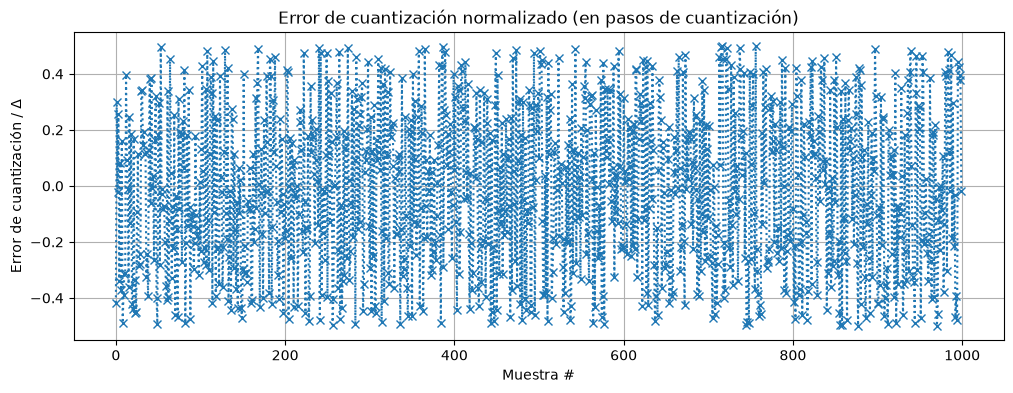

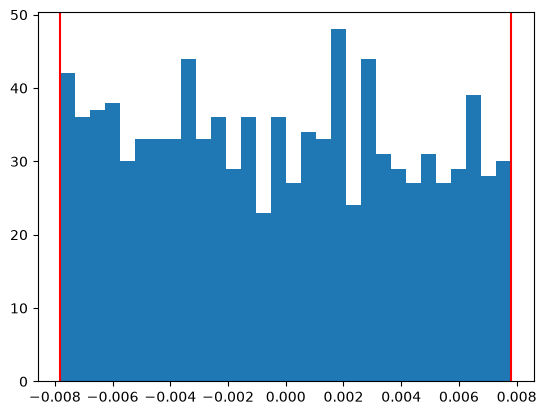

In [4]:
# -*- coding: utf-8 -*-
# -------------------------------------------------------------------
# IMPORTACION DE MODULOS
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest

# -------------------------------------------------------------------
# DEFINICION DE CONSTANTES
fs = 1000      # Frecuencia de muestreo (Hz)
N = 1000       # Cantidad de muestras
vmax = np.sqrt(2)   # Amplitud máxima de la senoide
dc = 0         # Offset (componente continua)
ff = 1         # Frecuencia de la senoide (Hz)
ph = 0         # Fase inicial (rad)

Psen = 1       # Potencia media de la senoide (Watt)
ur = 0         # Media del ruido

#%% Ruido analogico

B = 8 #Bits

Vfs = 2     #Vfulls

qq = 2 * Vfs / (2 ** B) #Paso de cuantizacion


Pq = qq**2 / 12 #Potencia del ruido de cuantizacion 

kn = 1     #Factor de escala 

Pn = kn * Pq  # ruido analogico

SNR = 10 * np.log10(Psen / Pn)

#%%
# FUNCIONES

def gen_sin(vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs):
    """
    Genera una señal senoidal.
    Retorna: vector de tiempos tt y la señal xx.
    """
    tt = np.arange(0, stop=nn/fs, step=1/fs)
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx

def gen_noise(Pn=Pn, ur=ur, nn=N):
    
    desv_est_r = np.sqrt(Pn)
    
    ruido = np.random.normal(ur, desv_est_r, nn)
    
    return ruido

# -------------------------------------------------------------------
#%% main

# 1. Generar la senoide
tt, xx = gen_sin(vmax, dc, ff, ph, N, fs) # xx es mi s

# 2. Generar el ruido
ruido = gen_noise() # ruido es mi n

# 3. Señal ruidosa (senoide + ruido) - USAMOS EL NOMBRE QUE USA EL PROFESOR
noisy_xx = xx + ruido # es mi sR[n]

# 4. Vector de frecuencias
frec = np.arange(0, N//2) * fs / N

# 5. FFT de la senoide pura
X_fft = np.fft.fft(xx)

# 6. Módulo de la FFT
modulo = np.abs(X_fft[:N//2]) / N
modulo[1:] = 2 * modulo[1:]

# 7. Gráfico de la transformada
plt.figure(figsize=(10, 5))

plt.stem(frec, modulo)

plt.xlim(0, fs/2)       # 0 a 500 Hz
plt.xticks(np.arange(0, 501, 50))

plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud")
plt.title("Transformada de Fourier de la senoide")
plt.grid(True)

plt.show()
# ===================================================================


#%% 

# Señal cuantizada 
xx_q = np.round( noisy_xx / qq) * qq   # Es mi sq[n] senal cuantizada

#%% Error de cuantización

nq = xx_q - noisy_xx

# Graficar señal ruidosa y señal cuantizada
plt.figure(figsize=(12, 6))
plt.plot( noisy_xx , ':x', label='Señal ruidosa (original)')
plt.plot(xx_q, ':v', label='Señal cuantizada')
plt.xlabel("Muestra #")
plt.ylabel("Amplitud [V]")
plt.title(f"Cuantización con B={B} bits (Δ = {qq:.4f} V)")
plt.legend()
plt.grid(True)

# Graficar el error de cuantización normalizado
plt.figure(figsize=(12, 4))
plt.plot(nq / qq, ':x')
plt.xlabel("Muestra #")
plt.ylabel("Error de cuantización / Δ")
plt.title("Error de cuantización normalizado (en pasos de cuantización)")
plt.grid(True)

plt.show()

plt.hist(nq, bins=30)
plt.axvline(x=-qq/2, color='r')
plt.axvline(x=qq/2, color='r')
plt.show()

## Conclusiones

Al comparar los resultados obtenidos para las distintas configuraciones, se observa que al disminuir \(k_n\) de 1 a \(1/10\), la señal presenta menor cantidad de ruido y se vuelve más estable, manteniendo el mismo paso de cuantización cuando \(B=4\).

Por otro lado, al aumentar la cantidad de bits de \(B=4\) a \(B=8\), el paso de cuantización disminuye considerablemente, por lo que los saltos de la señal cuantizada (la naranja ) son menores y esta se observa más uniforme y cercana a la señal original.

En conclusión, una menor potencia de ruido y una mayor cantidad de bits permiten obtener una señal digitalizada de mayor calidad.
